# A simple demo of the package

In [7]:
#%matplotlib notebook
import sys
sys.path.append('../')
import numpy as np
import pylab as plt
import seaborn as sns#; sns.set()
import pickle

import sparseRRR

In [8]:
def preprocess(data):
    X = data['counts'][:,data['mostVariableGenes']] / np.sum(data['counts'], axis=1) * 1e+6
    X = np.array(X)
    X = np.log2(X + 1)
    X = X - np.mean(X, axis=0)
    X = X / np.std(X, axis=0)

    Y = data['ephys']
    Y = Y - np.mean(Y, axis=0)
    Y = Y / np.std(Y, axis=0)
    
    return (X,Y)

In [9]:
Most_correlated = ['SLC8A1', 'SLC16A1', 'SMPX', 'ACTC1', 'SLC2A1', 'WNT2', 'SLIT2',
       'RYR2', 'COX5B', 'SLN', 'VIM', 'COX6C', 'CDH2', 'VDAC2', 'PDK1',
       'SFXN4', 'SLC20A2', 'KDR', 'KCNK1', 'IL6', 'COX7B', 'S100A4',
       'PKP2', 'NIPAL1', 'KCNJ2', 'SLC44A2', 'GREM1', 'FHL1', 'KCNE2',
       'HEY1', 'MYH6', 'VCL', 'HCN4', 'VDAC3', 'ATP2A2', 'SGCA', 'LBH',
       'MYL4', 'GATA4', 'TNNT2', 'COX8A', 'SIRPA', 'TBX5', 'COX7C',
       'MESP1', 'TNNI1', 'ACTN2', 'NKX2-5', 'SLC25A12', 'SOCS3', 'NFIA',
       'LOXL1', 'CACNA1D', 'HAND2', 'CAV3', 'ITGB5', 'MYH7', 'MYL7',
       'TPM2', 'IRX4', 'MYOM1', 'TNNI3', 'KCNK3', 'AKAP9', 'TRPM4',
       'HEY2', 'CACNA1C', 'GJA5', 'KCNH2', 'WT1', 'TBX3', 'ATOX1',
       'ATP1A1', 'MPC1', 'TCF21', 'NEK2', 'VCAM1', 'ISL1', 'NPPB',
       'SLMAP', 'ROR2', 'ITGA5', 'SERPINE1', 'KCNQ1', 'TBX2', 'MYH11',
       'EMILIN2', 'KCNA4', 'LUM', 'NANOG', 'EOMES', 'GYPA', 'KCND2',
       'ATP2B1', 'TMC7', 'DCN', 'ACTA1']
len(Most_correlated)

97

In [10]:
import pylab
import matplotlib
import copy
import pandas as pd
def color_cm(cmap,labels):
    NUM_COLORS = len(np.unique(labels))
    color = []
    color_idx = 0
    cm = pylab.get_cmap(cmap)
    for i in range(NUM_COLORS):
        color.append(matplotlib.colors.to_hex(cm(1. * i / NUM_COLORS)))  # color will now be an RGBA tuple
        
    color_dict = dict(zip(np.unique(labels), color)) 
    return color_dict



X = pickle.load(open('/Users/tangxin/Dropbox(HarvardUniversity)/Harvard_research&course/ElectroSeq/SupplementaryCardiacSubstrate/results/contact_data/gene_data_dpc.pkl', 'rb'))
Y = pickle.load(open('/Users/tangxin/Dropbox(HarvardUniversity)/Harvard_research&course/ElectroSeq/SupplementaryCardiacSubstrate/results/contact_data/ephys_data_dpc.pkl', 'rb'))


highly_variable = ['ACTA1', 'ACTN2', 'AKAP9', 'AKR1C2', 'AKR1C3', 'ALDH1A2', 'ANK2',
       'ATF3', 'ATP1A1', 'ATP2B1', 'BAK1', 'BGN', 'BIN1', 'CACNA1C', 'CACNA1D',
       'CACNA2D1', 'CACNB2', 'CASQ2', 'CAV3', 'CD44', 'CNN1', 'COL1A1',
       'COL1A2', 'COL3A1', 'COX7C', 'CPT1A', 'CRABP2', 'CRYM', 'CSRP3', 'DCN',
       'DDR2', 'EGR2', 'EPB41L5', 'FOSL1', 'GJA1', 'GYPA', 'HAND1', 'HEY2',
       'HOPX', 'HRC', 'IL1RL1', 'ILDR2', 'KCNA4', 'KCNA5', 'KCNC1', 'KCND2',
       'KCND3', 'KCNH2', 'KCNJ2', 'KCNJ3', 'KCNK1', 'KCNK6', 'LEFTY2', 'LMNA',
       'LOXL1', 'MEF2C', 'MESP1', 'MIXL1', 'MMP9', 'MPC1', 'MYH11', 'MYOM2',
       'NANOG', 'NDUFA9', 'NFIA', 'NIPAL1', 'NPPB', 'NR2F1', 'NR2F2', 'NT5E',
       'PCLAF', 'PDGFRA', 'PDGFRB', 'PDPN', 'PIEZO1', 'PRRX1', 'S100A4',
       'SIRPA', 'SLC20A2', 'SLC30A5', 'SLC43A1', 'SLC44A2', 'SLC6A16', 'SLIT2',
       'SLMAP', 'SLN', 'SNAP23', 'SOX9', 'SP6', 'TBX18', 'TBX5', 'TBXT',
       'TCF21', 'TFPI2', 'TJP1', 'TNNI3', 'UQCRFS1', 'VDAC2', 'WNT2', 'WT1']
Most_correlated = ['SLC8A1', 'SLC16A1', 'SMPX', 'ACTC1', 'SLC2A1', 'WNT2', 'SLIT2',
       'RYR2', 'COX5B', 'SLN', 'VIM', 'COX6C', 'CDH2', 'VDAC2', 'PDK1',
       'SFXN4', 'SLC20A2', 'KDR', 'KCNK1', 'IL6', 'COX7B', 'S100A4',
       'PKP2', 'NIPAL1', 'KCNJ2', 'SLC44A2', 'GREM1', 'FHL1', 'KCNE2',
       'HEY1', 'MYH6', 'VCL', 'HCN4', 'VDAC3', 'ATP2A2', 'SGCA', 'LBH',
       'MYL4', 'GATA4', 'TNNT2', 'COX8A', 'SIRPA', 'TBX5', 'COX7C',
       'MESP1', 'TNNI1', 'ACTN2', 'NKX2-5', 'SLC25A12', 'SOCS3', 'NFIA',
       'LOXL1', 'CACNA1D', 'HAND2', 'CAV3', 'ITGB5', 'MYH7', 'MYL7',
       'TPM2', 'IRX4', 'MYOM1', 'TNNI3', 'KCNK3', 'AKAP9', 'TRPM4',
       'HEY2', 'CACNA1C', 'GJA5', 'KCNH2', 'WT1', 'TBX3', 'ATOX1',
       'ATP1A1', 'MPC1', 'TCF21', 'NEK2', 'VCAM1', 'ISL1', 'NPPB',
       'SLMAP', 'ROR2', 'ITGA5', 'SERPINE1', 'KCNQ1', 'TBX2', 'MYH11',
       'EMILIN2', 'KCNA4', 'LUM', 'NANOG', 'EOMES', 'GYPA', 'KCND2',
       'ATP2B1', 'TMC7', 'DCN', 'ACTA1']
ion_channel = pd.read_csv('../ionchannel_gene.csv')['LIST2_ION CHANNAL GENES'].values


stage_label = np.array([sample.split('_')[0] for sample in X.index.values.tolist()])
ephys_label = np.array(pickle.load(open('/Users/tangxin/Dropbox(HarvardUniversity)/Harvard_research&course/ElectroSeq/results/contact_data/e_type_dpc.pkl', 'rb')))
gene_label = np.array(pickle.load(open('/Users/tangxin/Dropbox(HarvardUniversity)/Harvard_research&course/ElectroSeq/results/contact_data/t_type_dpc.pkl', 'rb')))

# X = X[Most_correlated]
genes = X.columns.values

print('Shape of X:', X.shape, '\nShape of Y:', Y.shape)

X = np.array(X)
Y = np.array(Y)

X = X/X.sum(axis=1)[:, np.newaxis]*np.median(X.sum(axis=1))
X = np.log1p(X)
X = X - np.mean(X, axis=0)
X = X / np.std(X, axis=0)

Y_orig = copy.deepcopy(Y)
Y = Y - np.mean(Y, axis=0)
Y = Y / np.std(Y, axis=0)
cmap = 'Set1'
color_stage = color_cm(cmap,stage_label)
cmap = 'Set2'
color_ephys = color_cm(cmap,ephys_label)
cmap = 'Set3'
color_gene = color_cm(cmap,gene_label)

stage_legend = dict(zip(np.unique(stage_label), np.unique(stage_label))) 
ephys_legend = dict(zip(np.unique(ephys_label), np.unique(ephys_label))) 
gene_legend = dict(zip(np.unique(gene_label), np.unique(gene_label))) 

Shape of X: (166, 201) 
Shape of Y: (166, 62)


CPU times: user 7.77 s, sys: 1.65 s, total: 9.42 s
Wall time: 1.21 s


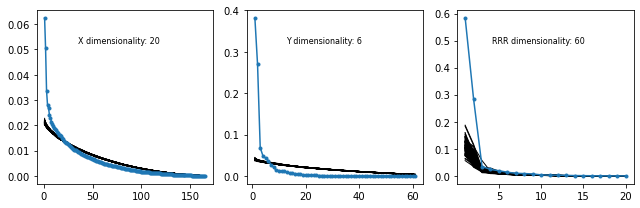

In [11]:
# A quick and dirty way to estimate the dimensionality

%time sparseRRR.dimensionality(X, Y)

1.......... Time: 0.0h  0m 13s


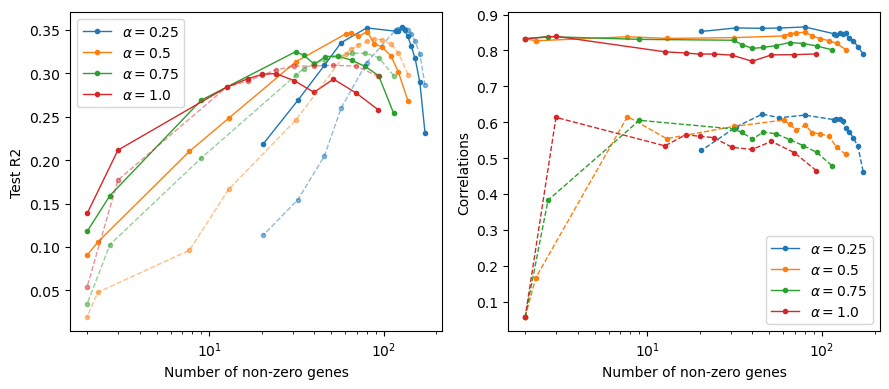

In [61]:
lambdas = np.concatenate((np.arange(.2,1.01,.1), np.arange(2,7)))
alphas = np.array([.25, .5, .75, 1])

cvResults = sparseRRR.elastic_rrr_cv(X, Y, alphas=alphas, lambdas=lambdas)

sparseRRR.plot_cv_results(*cvResults, alphas)
plt.savefig('../../SupplementaryCardiacSubstrate/results/RRR_bibiplot/RRR_bibiplot_allrelatedCV.pdf')

In [13]:
import pickle
cvresults = sparseRRR.elastic_rrr_cv(X, Y, rank=5, reps=1, folds=10, alphas=alphas, lambdas=lambdas)

lambdas = np.arange(.5,2,.1)
alphas = np.array([0.5])
ranks = np.arange(1, 20)

cvresults_rank = {}
for r in ranks:
    cvresults_rank[r] = sparseRRR.elastic_rrr_cv(X, Y, rank=r, reps=1, folds=10, alphas=alphas, lambdas=lambdas)
    


1.......... Time: 0.0h  2m 14s
1.......... Time: 0.0h  0m  5s
1.......... Time: 0.0h  0m  3s
1.......... Time: 0.0h  0m 14s
1.......... Time: 0.0h  0m 18s
1.......... Time: 0.0h  0m 23s
1.......... Time: 0.0h  0m 20s
1.......... Time: 0.0h  0m 19s
1.......... Time: 0.0h  0m 19s
1.......... Time: 0.0h  0m 36s
1.......... Time: 0.0h  0m 37s
1.......... Time: 0.0h  0m 36s
1.......... Time: 0.0h  0m 45s
1.......... Time: 0.0h  0m 40s
1.......... Time: 0.0h  0m 52s
1.......... Time: 0.0h  0m 45s
1.......... Time: 0.0h  0m 39s
1.......... Time: 0.0h  0m 40s
1.......... Time: 0.0h  0m 35s
1.......... Time: 0.0h  0m 50s


In [14]:
pickle.dump([cvresults, cvresults_rank], open('../../SupplementaryCardiacSubstrate/results/cvresults.pickle', 'wb'))

Text(0.5, 1.0, 'Rank-5 models')

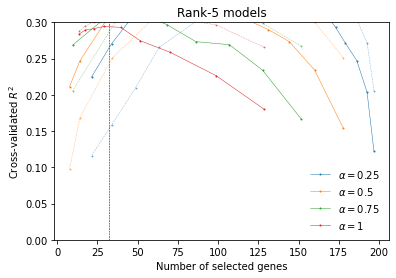

In [15]:
import warnings
import scipy
cvresults, cvresults_rank = pickle.load(open('../../SupplementaryCardiacSubstrate/results/cvresults.pickle', 'rb'))


r2, r2_relaxed, nonzeros, corrs, corrs_relaxed = cvresults
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    nonzeros = np.nanmean(nonzeros, axis=(0,1))
    r2_relaxed = np.nanmean(r2_relaxed, axis=(0,1))
    r2 = np.nanmean(r2, axis=(0,1))
    corrs_relaxed = np.nanmean(corrs_relaxed, axis=(0,1))

# fig = plt.figure(figsize=(3.5, 3.5))

plt.plot(nonzeros, r2_relaxed, '.-', linewidth=.5, markersize=2)
plt.gca().set_prop_cycle(None)
plt.plot(nonzeros, r2, '.--', linewidth=.5, alpha=.5, markersize=2)
plt.xlabel('Number of selected genes')
plt.ylabel('Cross-validated $R^2$')
plt.ylim([0,.3])
plt.legend(['$\\alpha='+str(a)+'$' for a in [0.25,.5, .75, 1]], frameon=False)
plt.plot([32,32],[0,.3],'k--', linewidth=.5, zorder=0)
plt.title('Rank-5 models')




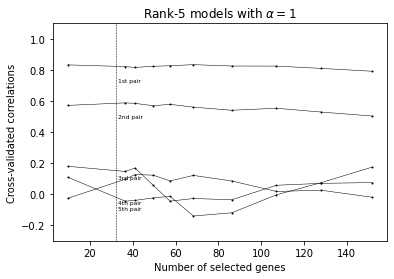

In [16]:

for k in range(corrs_relaxed.shape[2]):
    plt.plot(nonzeros[:,2], corrs_relaxed[:,2,k].squeeze(), 'k.-', linewidth=.5, markersize=2)
plt.xlabel('Number of selected genes')
plt.ylabel('Cross-validated correlations')
plt.ylim([-0.3,1.1])
plt.title(r'Rank-5 models with $\alpha=1$')
plt.plot([32,32],[-1,1.5],'k--', linewidth=.5, zorder=0)
for i,c in zip(['1st','2nd','3rd','4th','5th'], [.72,.49,.094,-0.062,-0.101]):
    plt.text(33, c, '{} pair'.format(i), color='k', fontsize=6)



ValueError: A value in x_new is below the interpolation range.

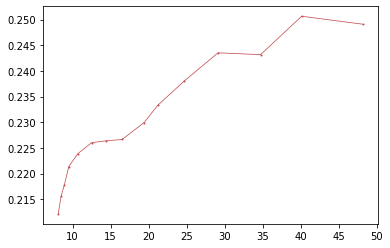

In [17]:

maxRank = len(cvresults_rank)
colA = np.array([76, 114, 176]) / 256
colB = np.array([196, 78, 82])  / 256
perf25 = np.zeros(maxRank+1)
for rank in range(1,maxRank+1):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        n = np.nanmean(cvresults_rank[rank][2], axis=(0,1))
        c = np.nanmean(cvresults_rank[rank][0], axis=(0,1))
        cr = np.nanmean(cvresults_rank[rank][1], axis=(0,1))
        f = scipy.interpolate.interp1d(n.squeeze(), cr.squeeze(), kind='linear')
        perf25[rank] = f(32)
    col = (colA * (rank-1)/(maxRank-1) + colB * (maxRank-rank)/(maxRank-1))
    plt.plot(n[:,0], cr[:,0], '.-', color=col, linewidth=.75, markersize=2)
# plt.ylim([.2,.45])
plt.xlabel('Number of selected genes')
plt.ylabel('Cross-validated $R^2$')
# plt.plot([25,25],[.2,.45],'k--', linewidth=.5, zorder=0)
# plt.text(40, .24, 'Rank 1', color=colB, fontsize=6)
# plt.text(55, .32, 'Rank 2', color=colB, fontsize=6)
# plt.text(60, .37, 'Rank 3', color=colB, fontsize=6)
# plt.text(65, .43, 'Rank 16', color=colA, fontsize=6)
plt.title(r'$\alpha=1$ models')



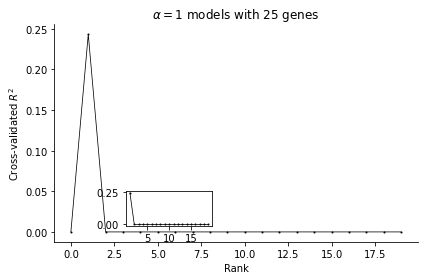

In [18]:

plt.plot(np.arange(0,maxRank+1), perf25[0:], 'k.-', linewidth=.75, markersize=2)
plt.xlabel('Rank')
plt.ylabel('Cross-validated $R^2$')
# plt.ylim([.2,.4])
plt.title(r'$\alpha=1$ models with 25 genes')

sns.despine()
plt.tight_layout()

ax = plt.axes([.3,.2,.2,.12])
plt.plot(np.arange(1,maxRank+1), perf25[1:], 'k.-', linewidth=.75, markersize=2)
# plt.ylim([.374,.376])

# fig.text(.01, .98,  'a', fontsize=8, fontweight='bold', va='top')
# fig.text(.51, .98,  'b', fontsize=8, fontweight='bold', va='top')
# fig.text(.01, .51,  'c', fontsize=8, fontweight='bold', va='top')
# fig.text(.51, .51,  'd', fontsize=8, fontweight='bold', va='top')

# plt.savefig('../figures/suppfigures/rrr-cv.png', dpi=300)
# plt.savefig('../figures/suppfigures/pdf/rrr-cv.pdf')

In [19]:
%time 
w,v = sparseRRR.relaxed_elastic_rrr(X, Y, rank=5, lambdau=1.5, alpha=0.5)

print('\nGenes selected: {}'.format(np.sum(w[:,0]!=0)))
print(', '.join(genes[w[:,0]!=0]))

CPU times: user 2 µs, sys: 1e+03 ns, total: 3 µs
Wall time: 5.25 µs

Genes selected: 48
ACTC1, AHCYL1, ALDH1A2, ATP2A2, BIN1, CDH2, COX5B, COX7C, COX8A, CUL5, DDR2, GATA4, HCN4, IL6, ITGA5, KCND3, KCNJ2, KCNK6, KCNQ1, LBH, LEFTY2, LOXL1, MESP1, MPC1, MYH6, MYH7, MYL4, NPPB, PDK1, RYR2, SERPINE1, SGCA, SHOX2, SLC16A1, SLC25A12, SLC2A1, SLC30A6, SLC44A2, SLC8A1, SLIT2, SMPX, SOCS3, TCF21, TNNT2, VCL, VDAC2, VDAC3, WNT2


In [20]:
# ephysName = ['bin'+str(i) for i in range(1,Y.shape[1]+1)]
ephysName = [str(i) for i in range(1,Y.shape[1]+1)]
print('\nephys selected: {}'.format(np.sum(v[:,0]!=0)))
print(', '.join(np.array(ephysName)[v[:,0]!=0]))


ephys selected: 62
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62


In [21]:
gene_name=[]
for i in range(10):
    %time w,v = sparseRRR.relaxed_elastic_rrr(X, Y, rank=5, lambdau=1.5, alpha=0.5)
    
    gene_name.append(genes[w[:,0]!=0])

CPU times: user 914 ms, sys: 253 ms, total: 1.17 s
Wall time: 149 ms
CPU times: user 871 ms, sys: 173 ms, total: 1.04 s
Wall time: 132 ms
CPU times: user 824 ms, sys: 334 ms, total: 1.16 s
Wall time: 152 ms
CPU times: user 852 ms, sys: 230 ms, total: 1.08 s
Wall time: 138 ms
CPU times: user 868 ms, sys: 205 ms, total: 1.07 s
Wall time: 136 ms
CPU times: user 911 ms, sys: 222 ms, total: 1.13 s
Wall time: 144 ms
CPU times: user 890 ms, sys: 333 ms, total: 1.22 s
Wall time: 159 ms
CPU times: user 889 ms, sys: 311 ms, total: 1.2 s
Wall time: 156 ms
CPU times: user 856 ms, sys: 202 ms, total: 1.06 s
Wall time: 134 ms
CPU times: user 882 ms, sys: 180 ms, total: 1.06 s
Wall time: 134 ms


In [22]:
np.array(['c']*10)

array(['c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c'], dtype='<U1')

In [23]:
final_name = np.array(set.intersection(*map(set,gene_name)))


In [44]:
###################################################
# Double biplot function
def bibiplot(X, Y, w, v, 
             YdimsNames=np.array([]), YdimsToShow=None,
             XdimsNames=np.array([]), XdimsToShow=None, 
             titles=[], xylim = 3, s=10,
             cellTypes=np.array([]), cellTypeColors={}, cellTypeLabels={},
             figsize=(9,5), axes=None,component=[0,1]):

    if XdimsToShow is None:
        nz = np.sum(np.abs(w), axis=1) != 0
        XdimsToShow = np.where(nz)[0]
    if YdimsToShow is None:
        nz = np.sum(np.abs(v), axis=1) != 0
        YdimsToShow = np.where(nz)[0]
    
    # Project and standardize
    Zx = X @ w[:,component]
    Zy = Y @ v[:,component]
    Zx = Zx / np.std(Zx, axis=0)
    Zy = Zy / np.std(Zy, axis=0)
    
    if not axes:
        plt.figure(figsize=figsize)
        plt.subplot(121, aspect='equal')
    else:
        plt.sca(axes[0])
    
    if cellTypes.size == 0:
        plt.scatter(Zx[:,0], Zx[:,1])
    else:
        for u in np.unique(cellTypes):
            if not cellTypeLabels:
                plt.scatter(Zx[cellTypes==u,0], Zx[cellTypes==u,1], color=cellTypeColors[u], s=s)
            else:
                plt.scatter(Zx[cellTypes==u,0], Zx[cellTypes==u,1], color=cellTypeColors[u], label=cellTypeLabels[u], s=s)
    plt.xlim([-xylim,xylim])
    plt.ylim([-xylim,xylim])
    plt.gca().set_xticklabels([])
    plt.gca().set_yticklabels([])
    plt.xlabel('Component 1')
    if component==[0,1]:
        plt.ylabel('Component 2')
    else:
        plt.ylabel('Component 3')
    if titles:
        plt.title(titles[0])
    if cellTypeLabels:
        plt.legend(bbox_to_anchor=(1.35, 1.0))
        
    if XdimsToShow.size > 0:
        scaleFactor = 2
        L = np.corrcoef(np.concatenate((Zx[:,:2], X), axis=1), rowvar=False)[2:,:2]
        
        x_pos = L[:,0]>=0
        y_pos = L[:,1]>=0
        
        L_color = np.array(['c']*len(L))
        L_color[x_pos & y_pos] = 'c'
        L_color[(~x_pos) & y_pos] = 'm'
        L_color[x_pos & (~y_pos)] = 'y'
        L_color[(~x_pos) & (~y_pos)] = 'k'
        for i in XdimsToShow:
            plt.plot([0, scaleFactor*L[i,0]], [0, scaleFactor*L[i,1]], linewidth=1, color=[.4, .4, .4])
            plt.plot([0, scaleFactor*L[i,0]], [0, scaleFactor*L[i,1]], linewidth=1, color=L_color[i])
            plt.text(scaleFactor*L[i,0]*1.2, scaleFactor*L[i,1]*1.2, XdimsNames[i], 
                     ha='center', va='center', color=[.4, .4, .4], fontsize=10)
        circ = plt.Circle((0,0), radius=scaleFactor, color=[.4, .4, .4], fill=False, linewidth=1)
        plt.gca().add_patch(circ)
    L_color_gene =L_color
    if not axes:
        plt.subplot(122, aspect='equal')
    else:
        if not axes[1]:
            return
        plt.sca(axes[1])
        
    if cellTypes.size == 0:
        plt.scatter(Zy[:,0], Zy[:,1], s=s)
    else:
        for u in np.unique(cellTypes):
            plt.scatter(Zy[cellTypes==u,0], Zy[cellTypes==u,1], color=cellTypeColors[u], s=s)
    plt.xlim([-xylim,xylim])
    plt.ylim([-xylim,xylim])
    plt.gca().set_xticklabels([])
    plt.gca().set_yticklabels([])
    plt.xlabel('Component 1')
    if component==[0,1]:
        plt.ylabel('Component 2')
    else:
        plt.ylabel('Component 3')
    if titles:
        plt.title(titles[1])
    plt.tight_layout()

    if YdimsToShow.size > 0:
        scaleFactor = 2
        L = np.corrcoef(np.concatenate((Zy[:,:2], Y), axis=1), rowvar=False)[2:,:2]
        
        x_pos = L[:,0]>=0
        y_pos = L[:,1]>=0
        
        L_color = np.array(['c']*len(L))
        L_color[x_pos & y_pos] = 'c'
        L_color[(~x_pos) & y_pos] = 'm'
        L_color[x_pos & (~y_pos)] = 'y'
        L_color[(~x_pos) & (~y_pos)] = 'k'
        
    
        for i in YdimsToShow:
            plt.plot([0, scaleFactor*L[i,0]], [0, scaleFactor*L[i,1]], linewidth=1, color=L_color[i])
            plt.text(scaleFactor*L[i,0]*1.2, scaleFactor*L[i,1]*1.2, YdimsNames[i], 
                     ha='center', va='center', color=[.4, .4, .4], fontsize=5)
        circ = plt.Circle((0,0), radius=scaleFactor, color=[.4, .4, .4], fill=False, linewidth=1)
        plt.gca().add_patch(circ)
    L_color_ephys =L_color
    return L_color_ephys, L_color_gene, XdimsToShow

In [45]:
%time bootCounts = sparseRRR.elastic_rrr_bootstrap(X, Y, lambdau=1.5, alpha=0.5)

args = np.argsort(bootCounts)[::-1]
predict_genes = []
print('')
for i in range(32):
    print('{:10} {:.2f}'.format(genes[args[i]], bootCounts[args[i]]))
    if bootCounts[args[i]]>=0.5:
        predict_genes.append(genes[args[i]])

.................................................................................................... 
CPU times: user 8.8 s, sys: 1.94 s, total: 10.7 s
Wall time: 1.36 s

VDAC3      1.00
VCL        1.00
MYH7       1.00
SLC8A1     1.00
SLC16A1    0.99
TNNT2      0.98
SLIT2      0.97
COX8A      0.96
COX7C      0.93
MYH6       0.90
VDAC2      0.88
CUL5       0.85
ACTC1      0.84
MESP1      0.82
SERPINE1   0.80
LOXL1      0.78
RYR2       0.76
TCF21      0.74
SLC25A12   0.72
MYL4       0.72
SOCS3      0.71
PDK1       0.69
LBH        0.69
ALDH1A2    0.68
HCN4       0.65
SGCA       0.65
WNT2       0.63
IL6        0.61
KCND3      0.60
BIN1       0.60
MPC1       0.59
SLC44A2    0.58


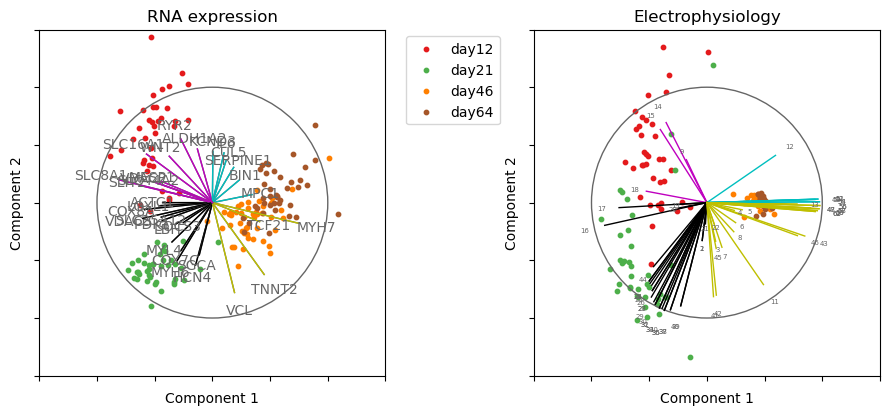

In [46]:
ephys_L_color, L_color_gene, XdimsToShow = bibiplot(X, Y, w, v, 
                   titles = ['RNA expression', 'Electrophysiology'],
                   cellTypes = stage_label, 
                   cellTypeColors = color_stage,
                   cellTypeLabels = stage_legend, 
                   YdimsNames = ephysName,
                   XdimsNames = genes,XdimsToShow=np.where(np.in1d(genes, np.array(predict_genes)))[0],figsize=(9,5),component=[0,1])
plt.savefig('../../SupplementaryCardiacSubstrate/results/RRR_bibiplot/RRR_bibiplot_dim1_2_all_substrate.pdf')
plt.show()
#sparseRRR.

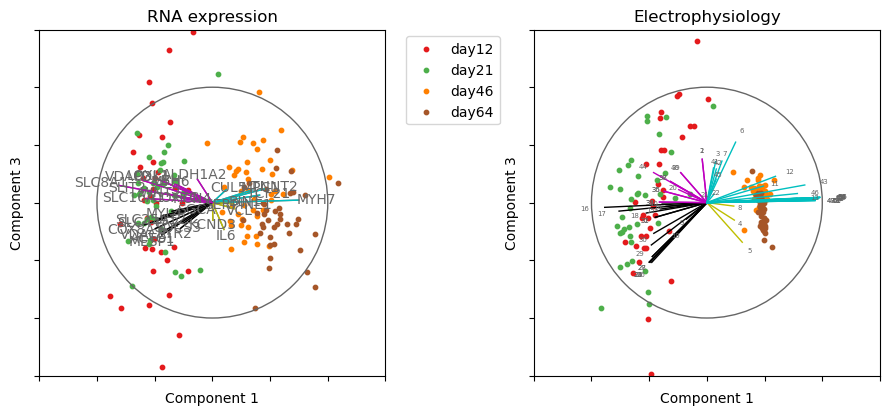

In [47]:

ephys_L_color, L_color_gene, XdimsToShow = bibiplot(X, Y, w, v, 
                   titles = ['RNA expression', 'Electrophysiology'],
                   cellTypes = stage_label, 
                   cellTypeColors = color_stage,
                   cellTypeLabels = stage_legend, 
                   YdimsNames = ephysName, 
                   XdimsNames = genes,XdimsToShow=np.where(np.in1d(genes, np.array(predict_genes)))[0],figsize=(9,5),component=[0,2])

plt.savefig('../../SupplementaryCardiacSubstrate/results/RRR_bibiplot/RRR_bibiplot_dim1_3_all_substrate.pdf')

plt.show()


In [48]:
%time bootCounts = sparseRRR.elastic_rrr_bootstrap(X, Y, lambdau=1.5, alpha=0.5)

args = np.argsort(bootCounts)[::-1]
print('')
for i in range(32):
    print('{:10} {:.2f}'.format(genes[args[i]], bootCounts[args[i]]))

.................................................................................................... 
CPU times: user 8.73 s, sys: 1.99 s, total: 10.7 s
Wall time: 1.36 s

VDAC3      1.00
VCL        1.00
MYH7       1.00
SLC8A1     1.00
SLC16A1    0.99
TNNT2      0.98
SLIT2      0.97
COX8A      0.96
COX7C      0.93
MYH6       0.90
VDAC2      0.88
CUL5       0.85
ACTC1      0.84
MESP1      0.82
SERPINE1   0.80
LOXL1      0.78
RYR2       0.76
TCF21      0.74
SLC25A12   0.72
MYL4       0.72
SOCS3      0.71
PDK1       0.69
LBH        0.69
ALDH1A2    0.68
HCN4       0.65
SGCA       0.65
WNT2       0.63
IL6        0.61
KCND3      0.60
BIN1       0.60
MPC1       0.59
SLC44A2    0.58


In [49]:
import pandas as pd
gne_order = np.argsort(L_color_gene[XdimsToShow])


X_heat = pd.DataFrame(X[:,XdimsToShow][:,gne_order],columns=genes[XdimsToShow][gne_order])


In [50]:
def color_cm(cmap,labels):
    NUM_COLORS = len(np.unique(labels))
    color = []
    color_idx = 0
    cm = pylab.get_cmap(cmap)
    for i in range(NUM_COLORS):
        color.append(cm(1. * i / NUM_COLORS)[:-1])  # color will now be an RGBA tuple
        
    color_dict = dict(zip(np.unique(labels), color)) 
    return color_dict
cmap = 'Set1'
color_stage = color_cm(cmap,stage_label)
cmap = 'Set2'
color_ephys = color_cm(cmap,ephys_label)
cmap = 'Set3'
color_gene = color_cm(cmap,gene_label)


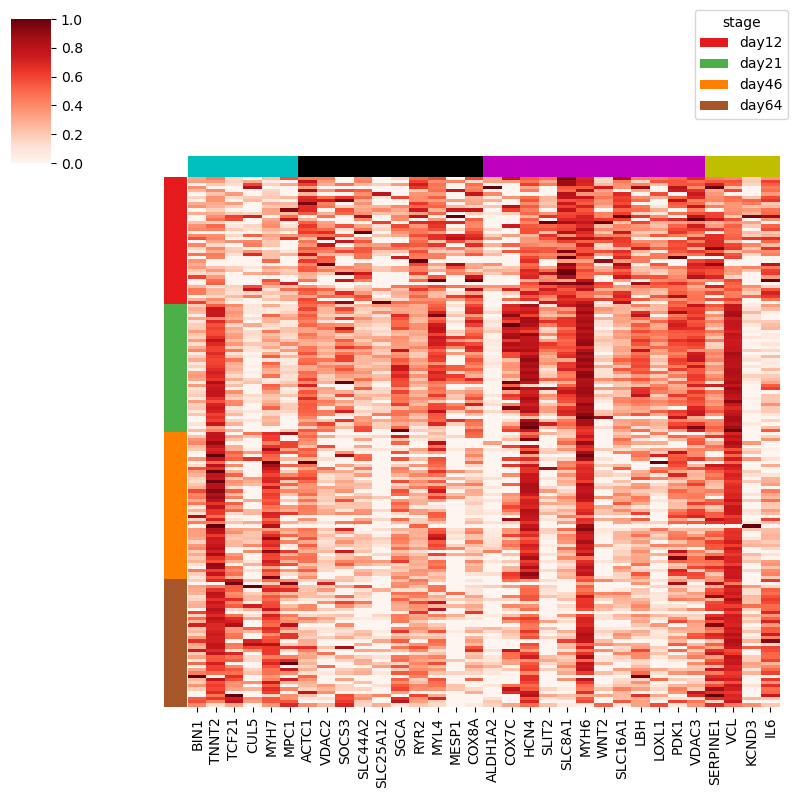

<Figure size 640x480 with 0 Axes>

In [51]:
from matplotlib.patches import Patch



network_colors_stage = tuple(map(tuple, np.array(np.vectorize(color_stage.get)(np.array(stage_label))).T))


g = sns.clustermap(X_heat, xticklabels=True,yticklabels=False, row_colors=network_colors_stage,col_colors=L_color_gene[XdimsToShow][gne_order], row_cluster=False, col_cluster=False,cmap='Reds',standard_scale=1,figsize=[8,8])
# g.cax.set_visible(False)

handles = [Patch(facecolor=color_stage[name]) for name in color_stage]
plt.legend(handles, color_stage, title='stage',
bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')
#sns.heatmap(out_final, xticklabels=True,cmap='Reds', ax=axs[0])
# plt.savefig('./results/e_c.pdf')
plt.show()

# plt.savefig('../results/RRR_bibiplot/gene_RRR_CMcorrelated.pdf')
plt.savefig('../../SupplementaryCardiacSubstrate/results/RRR_bibiplot/gene_RRR_CMcorrelated.pdf')



In [52]:
Y_avr=[]
for i in np.unique(stage_label):
    idx = np.array(np.where(stage_label == i))
    new_spikes = Y_orig[idx, :]
    if new_spikes.ndim == 3:
        new_spikes = new_spikes.squeeze()
    if new_spikes.ndim == 1:
        new_spikes = np.expand_dims(new_spikes, axis=0)
    Y_avr.append(np.mean(new_spikes, axis=0))
Y_avr = np.vstack(Y_avr)

In [53]:
# ephys_scale = np.hstack([np.repeat(ephys_set_avr.X[:,:6], factor_zo/factor_zi, axis=1),ephys_set_avr.X[:,22:],np.repeat(ephys_set_avr.X[:,6:22], factor_zo/factor_zi, axis=1),])



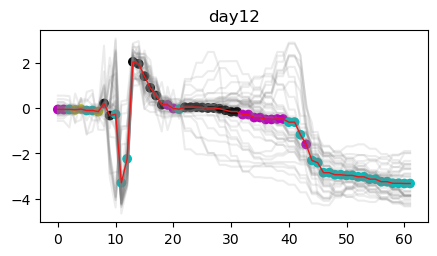

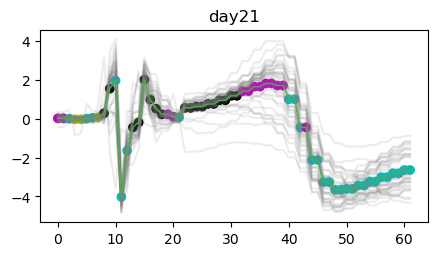

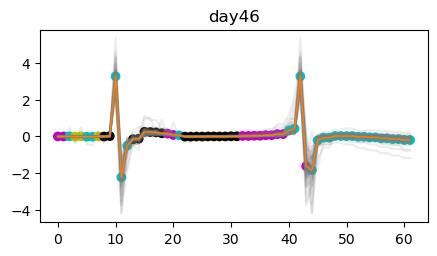

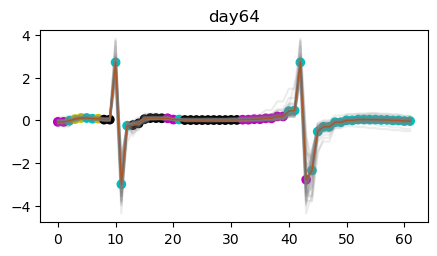

In [54]:
plt.rcParams.update(plt.rcParamsDefault)
for i,label in enumerate(np.unique(stage_label)):
    plt.figure(figsize=[5,2.5])
    
    idx = np.array(np.where(stage_label == label))
    new_spikes = Y_orig[idx, :]
    if new_spikes.ndim == 3:
        new_spikes = new_spikes.squeeze()
    if new_spikes.ndim == 1:
        new_spikes = np.expand_dims(new_spikes, axis=0)
    for sp in new_spikes:
        plt.plot(sp,c='gray',alpha=0.15)
        
    plt.plot(Y_avr[i,:],c=color_stage[label],linewidth=1)
    plt.scatter(range(Y_avr.shape[1]),Y_avr[i,:],c=ephys_L_color)
    plt.title(label)
    plt.grid(False)
    plt.show()

In [55]:
x_scale=np.hstack([np.arange(22),np.linspace(21.05, 23.95, num=40)])

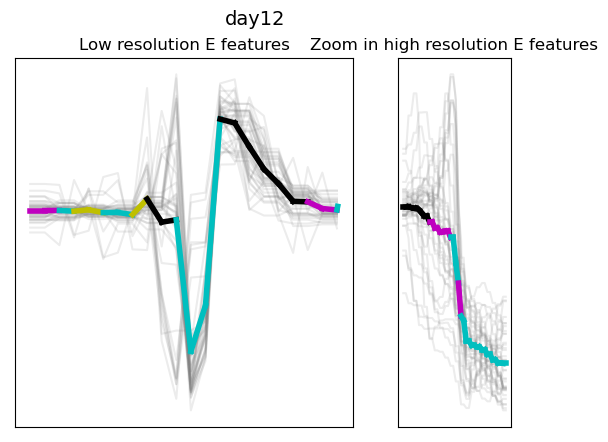

<Figure size 640x480 with 0 Axes>

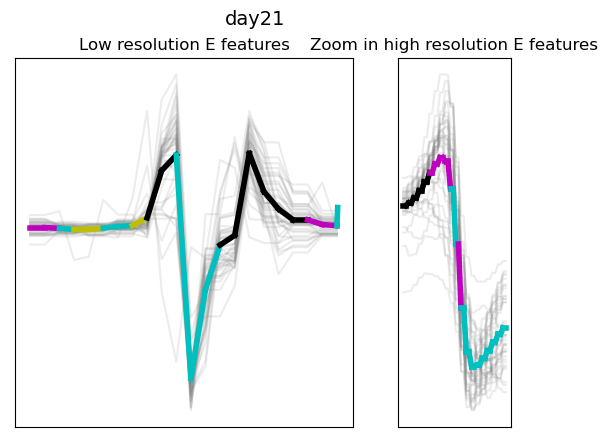

<Figure size 640x480 with 0 Axes>

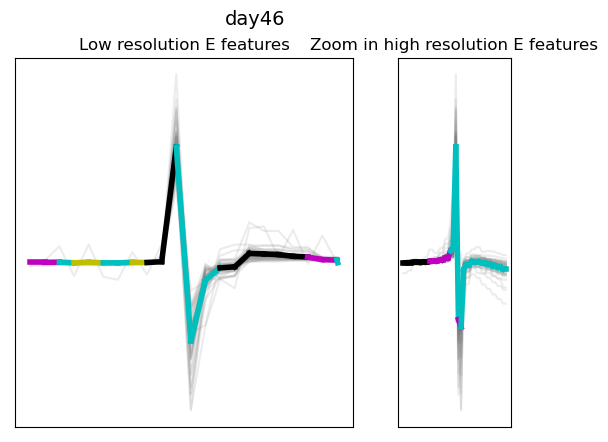

<Figure size 640x480 with 0 Axes>

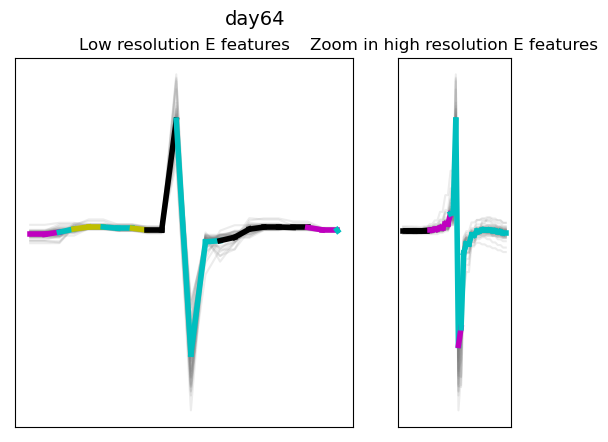

<Figure size 640x480 with 0 Axes>

In [56]:
for i,label in enumerate(np.unique(stage_label)):

    xy=np.vstack([x_scale,Y_avr[i,:]]).T
    fig, axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [3, 1]})

    idx = np.array(np.where(stage_label == label))
    new_spikes = Y_orig[idx, :]
    if new_spikes.ndim == 3:
        new_spikes = new_spikes.squeeze()
    if new_spikes.ndim == 1:
        new_spikes = np.expand_dims(new_spikes, axis=0)
    for sp in new_spikes:
        axs[0].plot(x_scale[:22],sp[:22],c='gray',alpha=0.15)
        axs[1].plot(x_scale[22:],sp[22:],c='gray',alpha=0.15)

    for idx,(start, stop) in enumerate(zip(xy[:22], xy[1:23])):
        x, y = zip(start, stop)
        axs[0].plot(x, y, color=ephys_L_color[idx],linewidth=4)

    for idx,(start, stop) in enumerate(zip(xy[22:], xy[23:])):
        x, y = zip(start, stop)                     
        axs[1].plot(x, y, color=ephys_L_color[idx+22],linewidth=4)

    axs[0].title.set_text('Low resolution E features')
    axs[1].title.set_text('Zoom in high resolution E features')
    fig.suptitle(label, fontsize=14)
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()
    plt.savefig('../../SupplementaryCardiacSubstrate/results/RRR_bibiplot/'+label+'bin_ephys.pdf')
    

[[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
  25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]]
[[41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64
  65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80]]
[[ 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
   99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116
  117 118 119 120 121 122 123 124 125 126]]
[[127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
  145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
  163 164 165 166]]
[[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
  25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]]
[[41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64
  65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80]]
[[ 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
   99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 

(<matplotlib.axes._subplots.AxesSubplot at 0x7feea1529610>,
 {'day12': array([-0.04964445, -0.05766687, -0.06593309, ...,  0.        ,
          0.        ,  0.        ]),
  'day21': array([0.02887713, 0.03006963, 0.03048673, ..., 0.        , 0.        ,
         0.        ]),
  'day46': array([-0.00512112, -0.00363697, -0.00564161, ...,  0.        ,
          0.        ,  0.        ]),
  'day64': array([-0.07206755, -0.0688725 , -0.06365186, ...,  0.        ,
          0.        ,  0.        ])})

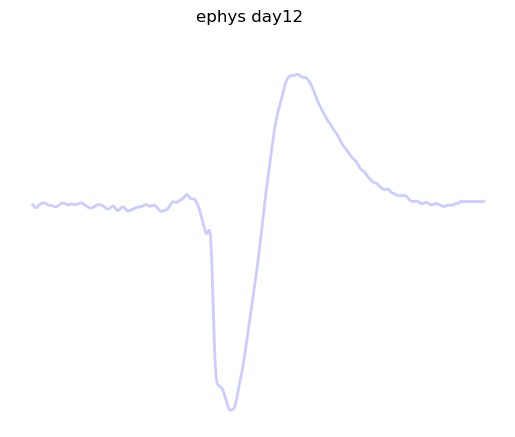

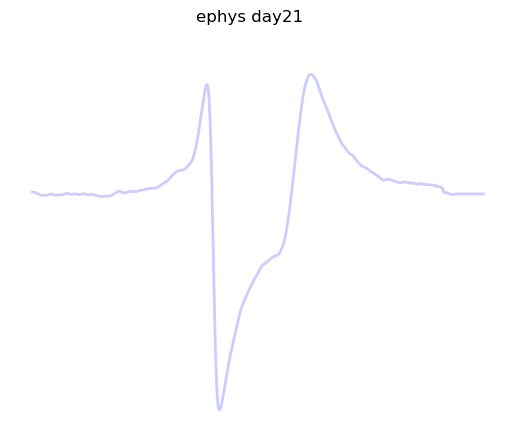

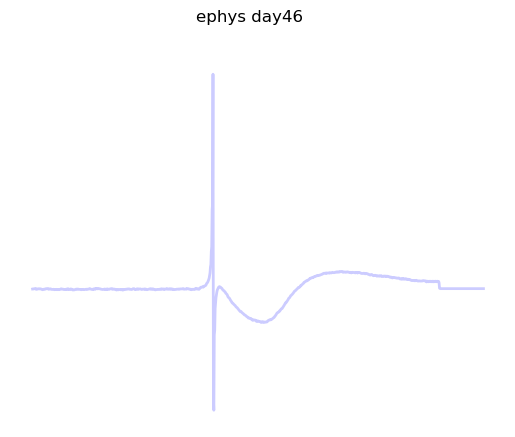

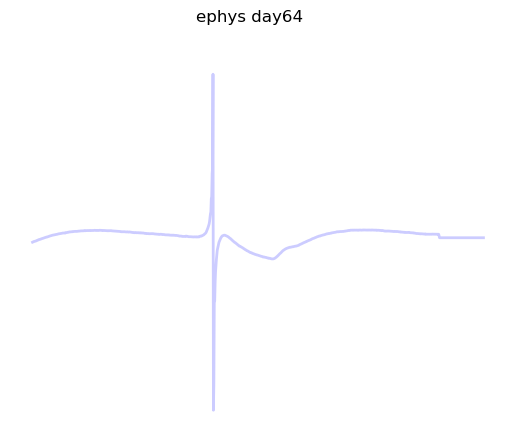

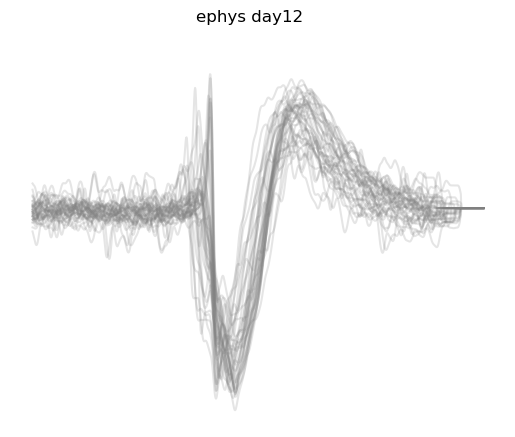

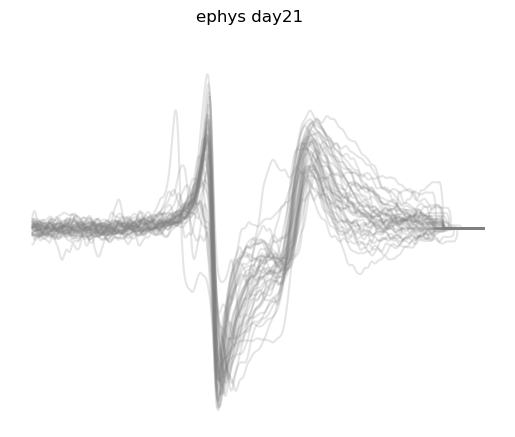

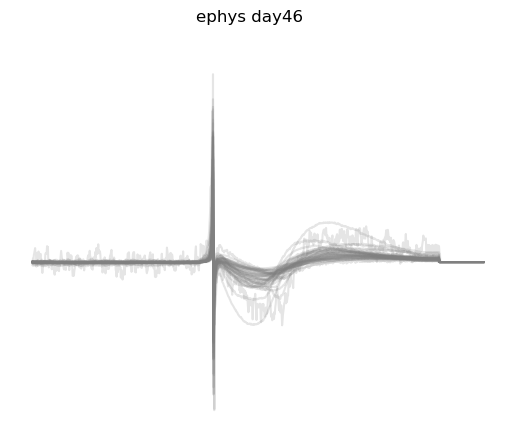

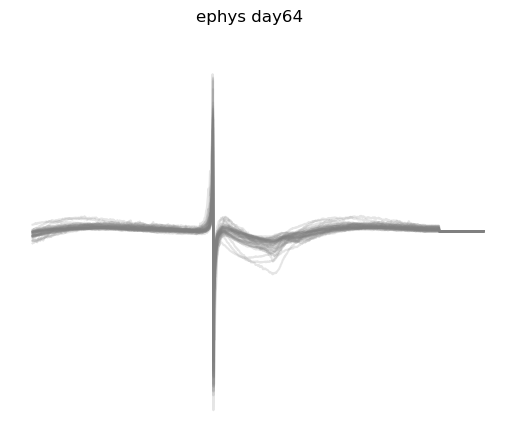

In [57]:

import sys
sys.path.append("../../Ephys/util/")
import widgets as wd
import numpy as np
import matplotlib.pyplot as plt
def spike_cluster_plot(averaged_spikes, labels, label_name, sampling_rate_new, 
                       plot_all=False, save_name=None,avr = 'b',bk=False):
    avr_spikes={}
    t = np.arange(averaged_spikes.shape[1]) / sampling_rate_new
    padding = int(averaged_spikes.shape[1]/2)
    for i in np.unique(labels):
        idx = np.array(np.where(labels == i))
        print(idx + 1)
        new_spikes = averaged_spikes[idx, :]
        if new_spikes.ndim == 3:
            new_spikes = new_spikes.squeeze()
        if new_spikes.ndim == 1:
            new_spikes = np.expand_dims(new_spikes, axis=0)

        fig, ax = plt.subplots()
        #averaged_spike, new_spikes=spike_aline_average(new_spikes,n_pad_left=padding,n_pad_right=padding,detect_sign = 1)
        t = np.arange(new_spikes.shape[1]) / sampling_rate_new
        averaged_spike = np.mean(new_spikes, axis=0)
        # new_spikes = wd.align_spikes(new_spikes,new_samp=sampling_rate_new,detect_sign=1)
        ax = averaged_spike_plot(new_spikes, averaged_spike, t,ax,avr,bk)
        ax.axis('off')
        fig.suptitle(label_name + str(i))
        if save_name:
            plt.savefig('../../SupplementaryCardiacSubstrate/GeneUMAP&Trace/'+label_name + str(i)+save_name, transparent=True)

        avr_spikes[i] = averaged_spike
    return ax,avr_spikes
def averaged_spike_plot(spikes, averaged_spike, t,ax , avr = 'b',bk=False):
    if bk:
        ax.plot(t, spikes.transpose(), color='0.5', alpha=0.2)
    if avr:
        ax.plot(t, averaged_spike, linewidth=2,color='b', alpha=0.2)
    return ax

RRR_raw = wd.load_obj('../../SupplementaryCardiacSubstrate/RRR_raw_data.pkl')
stage = wd.load_obj('../../SupplementaryCardiacSubstrate/stage_label.pkl')


ax,avr_spikes = spike_cluster_plot(RRR_raw, stage, 'ephys ', 1,save_name=None,avr = 'b',bk=False)
spike_cluster_plot(RRR_raw, stage, 'ephys ', 1,avr = False,bk=True,save_name='RRRbase_trace_substrate.png')



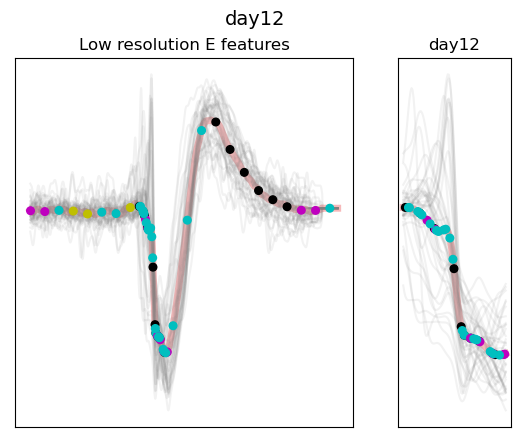

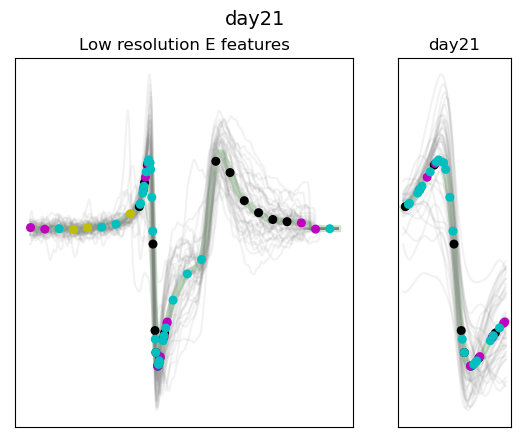

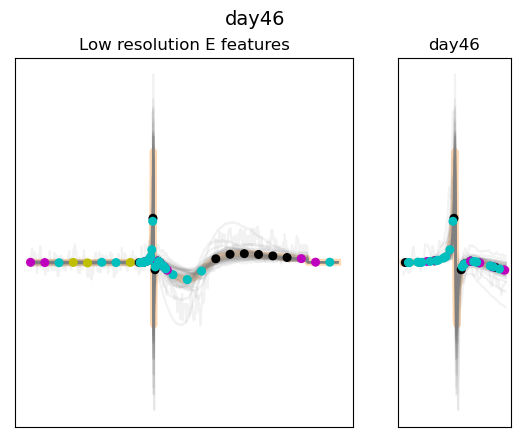

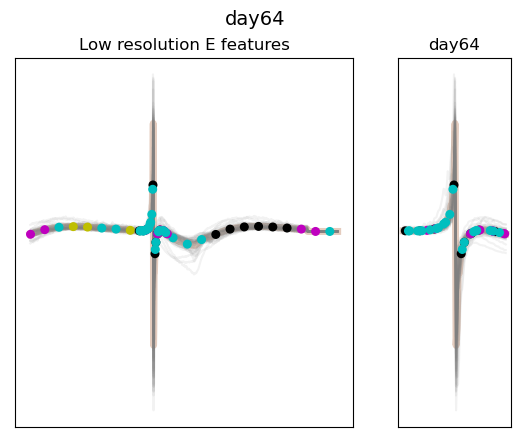

In [58]:

x_avr_zo = np.arange(1,len(avr_spikes['day12']),len(avr_spikes['day12'])//22+1)
x_avr_zi = np.random.choice(np.arange(423-50,423+50), 40)
x_var_all = np.hstack([x_avr_zo,x_avr_zi])
plt.rcParams.update(plt.rcParamsDefault)
for i,label in enumerate(np.unique(stage_label)):
    fig, axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [3, 1]})

    
    idx = np.array(np.where(stage_label == label))
    new_spikes = RRR_raw[idx, :]
    if new_spikes.ndim == 3:
        new_spikes = new_spikes.squeeze()
    if new_spikes.ndim == 1:
        new_spikes = np.expand_dims(new_spikes, axis=0)

    axs[0].scatter(x_var_all,avr_spikes[label][x_var_all],c=ephys_L_color,zorder=1,s=30)
    axs[1].scatter(x_avr_zi,avr_spikes[label][x_avr_zi],c=ephys_L_color[22:],zorder=1,s=30)

    axs[0].plot(avr_spikes[label],c=color_stage[label],linewidth=5,zorder=-1,alpha=0.3)
    axs[1].plot(range(423-50,423+50),avr_spikes[label][423-50:423+50],c=color_stage[label],linewidth=5,zorder=-1,alpha=0.3)
    for sp in new_spikes:
        axs[0].plot(sp,c='gray',alpha=0.1,zorder=-1)
        axs[1].plot(range(423-50,423+50),sp[423-50:423+50],c='gray',alpha=0.1,zorder=-1)
    
    axs[0].title.set_text('Low resolution E features')
    axs[1].title.set_text('Zoom in high resolution E features')
    fig.suptitle(label, fontsize=14)
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.title(label)
    plt.grid(False)
    plt.savefig('../../SupplementaryCardiacSubstrate/results/RRR_bibiplot/'+label+'bin_ephys_CMcorrelated_substrate.pdf')

    plt.show()

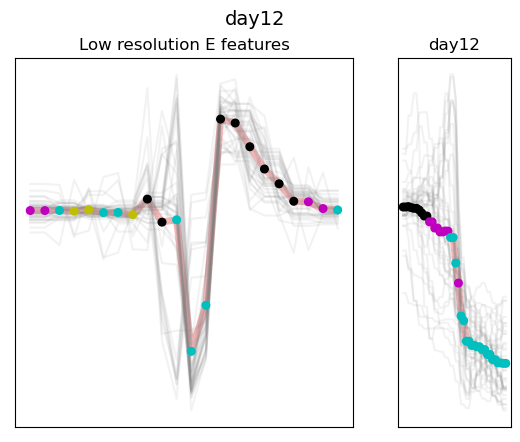

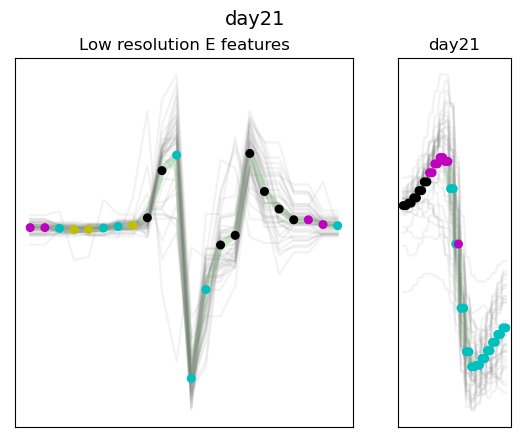

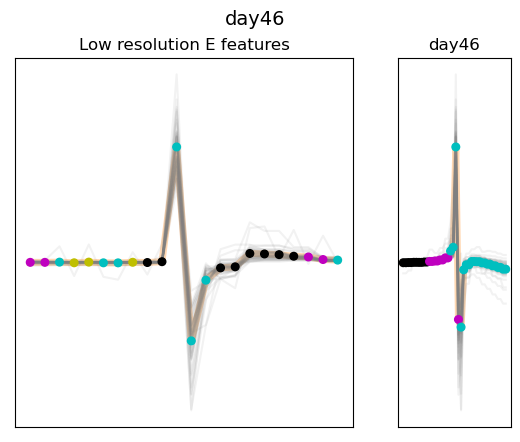

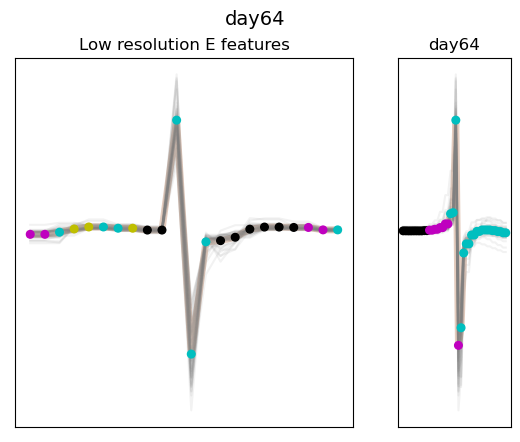

In [60]:
plt.rcParams.update(plt.rcParamsDefault)




for i,label in enumerate(np.unique(stage_label)):
    fig, axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [3, 1]})

    
    idx = np.array(np.where(stage_label == label))
    new_spikes = Y_orig[idx, :]
    if new_spikes.ndim == 3:
        new_spikes = new_spikes.squeeze()
    if new_spikes.ndim == 1:
        new_spikes = np.expand_dims(new_spikes, axis=0)

    axs[0].scatter(range(Y_avr[:,:22].shape[1]),Y_avr[i,:22],c=ephys_L_color[:22],zorder=1,s=30)
    axs[1].scatter(range(Y_avr[:,22:].shape[1]),Y_avr[i,22:],c=ephys_L_color[22:],zorder=1,s=30)

    axs[0].plot(Y_avr[i,:22],c=color_stage[label],linewidth=5,zorder=-1,alpha=0.3)
    axs[1].plot(Y_avr[i,22:],c=color_stage[label],linewidth=5,zorder=-1,alpha=0.3)
    for sp in new_spikes:
        axs[0].plot(range(len(sp[:22])),sp[:22],c='gray',alpha=0.1,zorder=-1)
        axs[1].plot(range(len(sp[22:])),sp[22:],c='gray',alpha=0.1,zorder=-1)

#     for idx,(start, stop) in enumerate(zip(xy[:22], xy[1:23])):
#         x, y = zip(start, stop)
#         axs[0].plot(x, y,c=color_stage[label],linewidth=1,zorder=-1)
#         axs[0].scatter(range(Y_avr[:,:22].shape[1]),Y_avr[i,:22],c=ephys_L_color[:22],zorder=1,s=5)


#     for idx,(start, stop) in enumerate(zip(xy[22:], xy[23:])):
#         x, y = zip(start, stop)                     
#         axs[1].plot(x, y, color=ephys_L_color[idx+22],linewidth=4)
#         axs[1].scatter(range(Y_avr[:,22:].shape[1]),Y_avr[i,22:],c=ephys_L_color[22:],zorder=1,s=5)

    
    axs[0].title.set_text('Low resolution E features')
    axs[1].title.set_text('Zoom in high resolution E features')
    fig.suptitle(label, fontsize=14)
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.title(label)
    plt.grid(False)
#     plt.savefig('../results/RRR_bibiplot/'+label+'bin_ephys_v2.pdf')
    plt.savefig('../../SupplementaryCardiacSubstrate/results/RRR_bibiplot/'+label+'bin_ephys_v2_substrate.pdf')


    plt.show()

In [192]:
Y_orig_zo = np.repeat(Y_orig[:,:22], 20, axis=1)
ephys_L_color_zo = np.repeat(ephys_L_color[:22], 20)
Y_orig_zi = Y_orig[:,22:]
ephys_L_color_zi = ephys_L_color[22:]



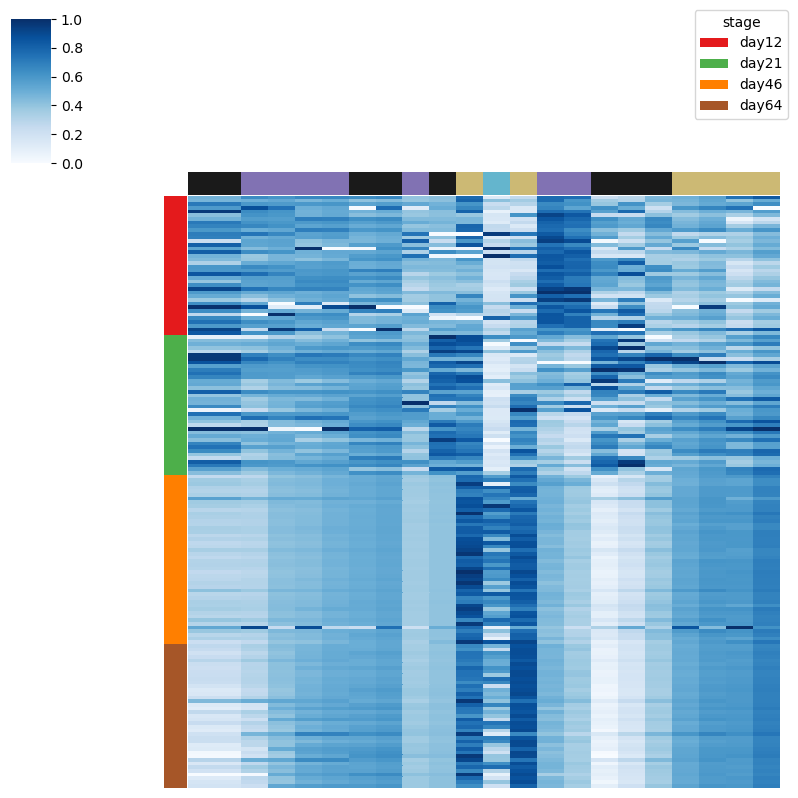

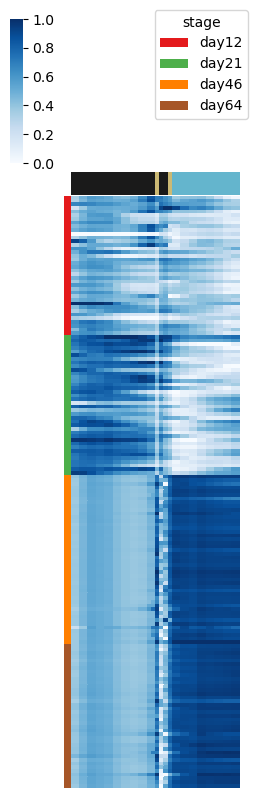

<Figure size 640x480 with 0 Axes>

In [33]:
from matplotlib.patches import Patch



network_colors_stage = tuple(map(tuple, np.array(np.vectorize(color_stage.get)(np.array(stage_label))).T))


g = sns.clustermap(Y_orig_zo, xticklabels=False,yticklabels=False, row_colors=network_colors_stage,col_colors=ephys_L_color_zo, row_cluster=False, col_cluster=False,cmap='Blues',standard_scale=1,figsize=[8,8])
# g.cax.set_visible(False)

handles = [Patch(facecolor=color_stage[name]) for name in color_stage]
plt.legend(handles, color_stage, title='stage',
bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')
#sns.heatmap(out_final, xticklabels=True,cmap='Reds', ax=axs[0])
# plt.savefig('./results/e_c.pdf')
plt.savefig('../results/RRR_bibiplot/zoom_out_heatmap_ephys.pdf')
plt.show()


g = sns.clustermap(Y_orig_zi, xticklabels=False,yticklabels=False, row_colors=network_colors_stage,col_colors=ephys_L_color_zi, row_cluster=False, col_cluster=False,cmap='Blues',standard_scale=1,figsize=[2.5,8])
# g.cax.set_visible(False)

handles = [Patch(facecolor=color_stage[name]) for name in color_stage]
plt.legend(handles, color_stage, title='stage',
bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')
#sns.heatmap(out_final, xticklabels=True,cmap='Reds', ax=axs[0])
# plt.savefig('./results/e_c.pdf')
plt.show()
plt.savefig('../results/RRR_bibiplot/zoom_in_heatmap_ephys.pdf')



In [34]:
Y_orig_zo = np.repeat(Y_orig[:,:22], 20, axis=1)
ephys_L_color_zo = np.repeat(ephys_L_color[:22], 20)
Y_orig_zi = Y_orig[:,22:]
ephys_L_color_zi = ephys_L_color[22:]

Y_orig_scale = np.hstack([Y_orig_zo[:,:10*20],Y_orig_zi,Y_orig_zo[:,10*20:]])
ephys_L_color_scale = np.concatenate([ephys_L_color_zo[:10*20],ephys_L_color_zi,ephys_L_color_zo[10*20:]])


NameError: name 'out_final' is not defined

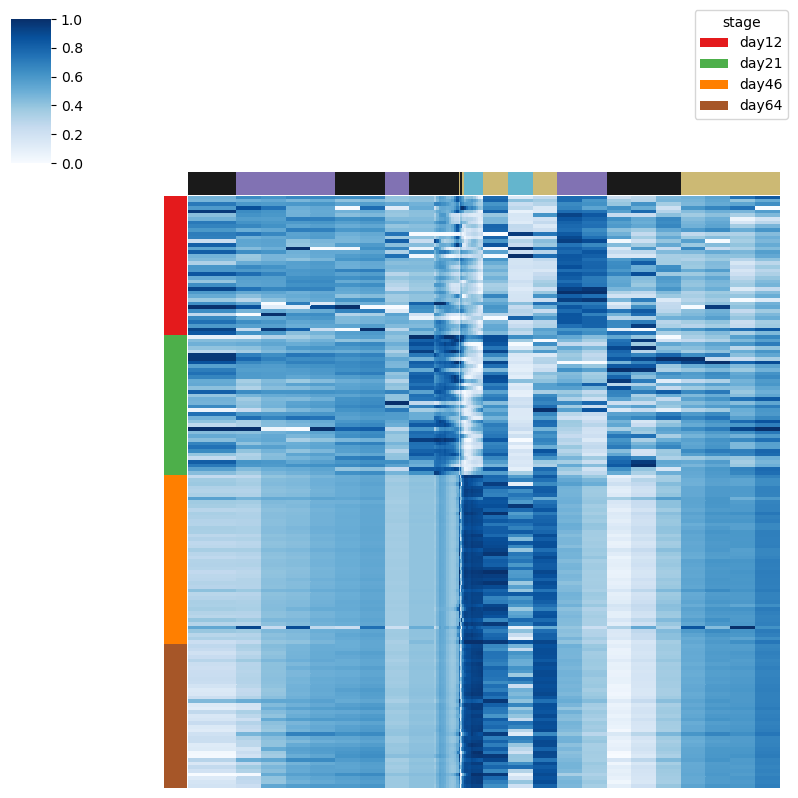

In [35]:
g = sns.clustermap(Y_orig_scale, xticklabels=False,yticklabels=False, row_colors=network_colors_stage,col_colors=ephys_L_color_scale, row_cluster=False, col_cluster=False,cmap='Blues',standard_scale=1,figsize=[8,8])
# g.cax.set_visible(False)

handles = [Patch(facecolor=color_stage[name]) for name in color_stage]
plt.legend(handles, color_stage, title='stage',
bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')
sns.heatmap(out_final, xticklabels=True,cmap='Reds', ax=axs[0])
plt.savefig('./results/e_c.pdf')
plt.show()

g = sns.clustermap(Y_orig_zi, xticklabels=False,yticklabels=False, row_colors=network_colors_stage,col_colors=ephys_L_color_zi, row_cluster=False, col_cluster=False,cmap='Blues',standard_scale=1,figsize=[8,8])
# g.cax.set_visible(False)

handles = [Patch(facecolor=color_stage[name]) for name in color_stage]
plt.legend(handles, color_stage, title='stage',
bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')
#sns.heatmap(out_final, xticklabels=True,cmap='Reds', ax=axs[0])
# plt.savefig('./results/e_c.pdf')
plt.show()

In [36]:
from matplotlib.patches import Patch



network_colors_stage = tuple(map(tuple, np.array(np.vectorize(color_stage.get)(np.array(stage_label))).T))




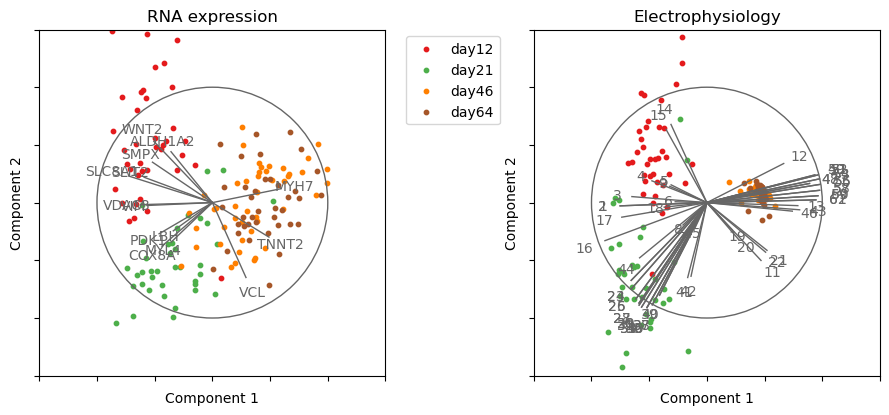

In [37]:

sparseRRR.bibiplot(X, Y, w, v, 
                   titles = ['RNA expression', 'Electrophysiology'],
                   cellTypes = stage_label, 
                   cellTypeColors = color_stage,
                   cellTypeLabels = stage_legend, 
                   YdimsNames = ephysName, 
                   XdimsNames = genes)
plt.show()

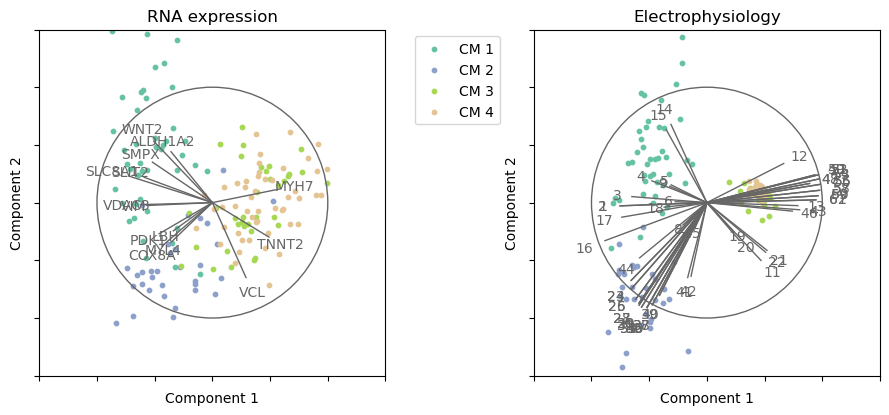

In [38]:
sparseRRR.bibiplot(X, Y, w, v, 
                   titles = ['RNA expression', 'Electrophysiology'],
                   cellTypes = ephys_label, 
                   cellTypeColors = color_ephys,
                   cellTypeLabels = ephys_legend, 
                   YdimsNames = ephysName, 
                   XdimsNames = genes)

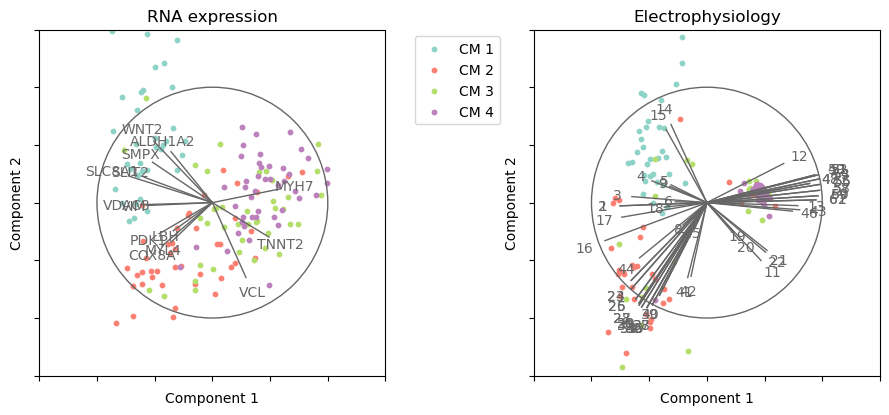

In [39]:
sparseRRR.bibiplot(X, Y, w, v, 
                   titles = ['RNA expression', 'Electrophysiology'],
                   cellTypes = gene_label, 
                   cellTypeColors = color_gene,
                   cellTypeLabels = gene_legend, 
                   YdimsNames = ephysName, 
                   XdimsNames = genes)